In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)


project_root = Path.cwd().parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "vic_demand_2024-07_to_2026-06.parquet"
)

df = pd.read_parquet(data_path)

df = df[
    df["SETTLEMENTDATE"] < pd.Timestamp("2026-07-01")
].copy()

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

In [2]:
FORECAST_HORIZON = 6

df["FORECAST_TIME"] = (
    df["SETTLEMENTDATE"]
    + pd.Timedelta(minutes=30)
)

df["target_30m"] = (
    df["TOTALDEMAND"]
    .shift(-FORECAST_HORIZON)
)

# Recent demand information available at forecast time
df["demand_current"] = df["TOTALDEMAND"]
df["demand_lag_5m"] = df["TOTALDEMAND"].shift(1)
df["demand_lag_30m"] = df["TOTALDEMAND"].shift(6)
df["demand_lag_1h"] = df["TOTALDEMAND"].shift(12)

# Demand at the same target time on previous days
df["same_time_yesterday"] = (
    df["TOTALDEMAND"]
    .shift(288 - FORECAST_HORIZON)
)

df["same_time_last_week"] = (
    df["TOTALDEMAND"]
    .shift(2016 - FORECAST_HORIZON)
)

# Calendar information for the time being forecast
target_minute_of_day = (
    df["FORECAST_TIME"].dt.hour * 60
    + df["FORECAST_TIME"].dt.minute
)

target_day_of_week = df["FORECAST_TIME"].dt.dayofweek
target_month = df["FORECAST_TIME"].dt.month

# Cyclical encodings
df["time_sin"] = np.sin(
    2 * np.pi * target_minute_of_day / 1440
)
df["time_cos"] = np.cos(
    2 * np.pi * target_minute_of_day / 1440
)

df["dow_sin"] = np.sin(
    2 * np.pi * target_day_of_week / 7
)
df["dow_cos"] = np.cos(
    2 * np.pi * target_day_of_week / 7
)

df["month_sin"] = np.sin(
    2 * np.pi * (target_month - 1) / 12
)
df["month_cos"] = np.cos(
    2 * np.pi * (target_month - 1) / 12
)

In [3]:
features = [
    "demand_current",
    "demand_lag_5m",
    "demand_lag_30m",
    "demand_lag_1h",
    "same_time_yesterday",
    "same_time_last_week",
    "time_sin",
    "time_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_df = df.dropna(
    subset=features + ["target_30m"]
).copy()

train = model_df[
    model_df["FORECAST_TIME"] < "2026-03-01"
].copy()

validation = model_df[
    (model_df["FORECAST_TIME"] >= "2026-03-01")
    & (model_df["FORECAST_TIME"] < "2026-05-01")
].copy()

test = model_df[
    (model_df["FORECAST_TIME"] >= "2026-05-01")
    & (model_df["FORECAST_TIME"] < "2026-07-01")
].copy()

print(f"Train:      {len(train):,}")
print(f"Validation: {len(validation):,}")
print(f"Test:       {len(test):,}")

Train:      173,087
Validation: 17,568
Test:       17,568


In [4]:
X_train = train[features]
y_train = train["target_30m"]

X_validation = validation[features]
y_validation = validation["target_30m"]

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train,
)

validation["linear_forecast"] = (
    linear_model.predict(X_validation)
)

linear_mae = mean_absolute_error(
    y_validation,
    validation["linear_forecast"],
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation["linear_forecast"],
    )
)

print(f"Linear regression MAE:  {linear_mae:.1f} MW")
print(f"Linear regression RMSE: {linear_rmse:.1f} MW")

Linear regression MAE:  107.5 MW
Linear regression RMSE: 139.5 MW


In [5]:
validation["persistence_forecast"] = (
    validation["demand_current"]
)

persistence_mae = mean_absolute_error(
    validation["target_30m"],
    validation["persistence_forecast"],
)

linear_mae = mean_absolute_error(
    validation["target_30m"],
    validation["linear_forecast"],
)

improvement = (
    (persistence_mae - linear_mae)
    / persistence_mae
    * 100
)

comparison_results = pd.DataFrame(
    {
        "Model": [
            "Persistence",
            "Linear regression",
        ],
        "MAE_MW": [
            persistence_mae,
            linear_mae,
        ],
    }
)

print(comparison_results.to_string(index=False))
print()
print(
    f"Improvement over persistence: "
    f"{improvement:.1f}%"
)

            Model     MAE_MW
      Persistence 163.641802
Linear regression 107.538958

Improvement over persistence: 34.3%


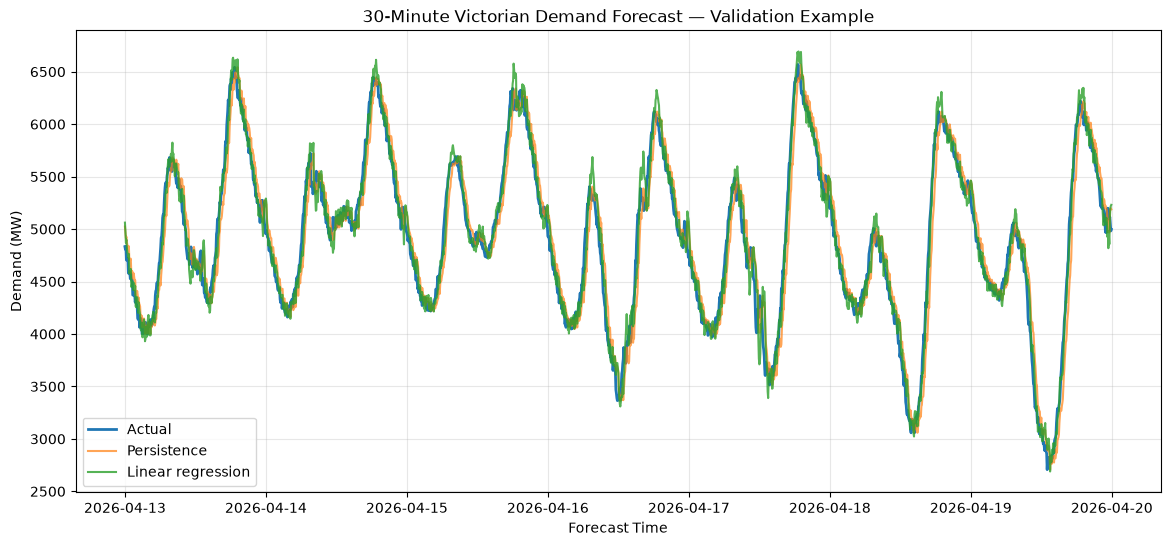

In [6]:
plot_start = pd.Timestamp("2026-04-13")
plot_end = plot_start + pd.Timedelta(days=7)

plot_data = validation[
    (validation["FORECAST_TIME"] >= plot_start)
    & (validation["FORECAST_TIME"] < plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["target_30m"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["persistence_forecast"],
    label="Persistence",
    alpha=0.7,
)

plt.plot(
    plot_data["FORECAST_TIME"],
    plot_data["linear_forecast"],
    label="Linear regression",
    alpha=0.8,
)

plt.title(
    "30-Minute Victorian Demand Forecast — Validation Example"
)
plt.xlabel("Forecast Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Linear regression

A linear regression model combining recent demand, historical demand at
comparable times, and calendar features substantially improved on the
persistence benchmark.

On the validation period:

- Persistence MAE: 163.6 MW
- Linear regression MAE: 107.5 MW
- Linear regression RMSE: 139.5 MW

This represents a 34.3% reduction in MAE relative to persistence.

Visual inspection suggests that the main improvement comes during periods
when demand is changing rapidly. Persistence necessarily lags these movements,
while the regression model can infer short-term direction from recent demand
observations.

In [7]:
validation["linear_error"] = (
    validation["target_30m"]
    - validation["linear_forecast"]
)

validation["linear_absolute_error"] = (
    validation["linear_error"].abs()
)

validation["target_hour"] = (
    validation["FORECAST_TIME"].dt.hour
)

validation["target_day_name"] = (
    validation["FORECAST_TIME"].dt.day_name()
)

In [8]:
error_by_hour = (
    validation.groupby("target_hour")
    .agg(
        MAE=("linear_absolute_error", "mean"),
        RMSE=(
            "linear_error",
            lambda x: np.sqrt(np.mean(x**2)),
        ),
    )
)

error_by_hour

,MAE,RMSE
target_hour,,
0,126.109888,154.156673
1,68.482937,83.813643
2,64.626866,79.613694
3,63.751987,80.728380
4,71.035062,87.492663
5,110.667751,132.565601
6,116.939852,141.476484
7,149.905163,184.073795
8,138.474923,171.582543


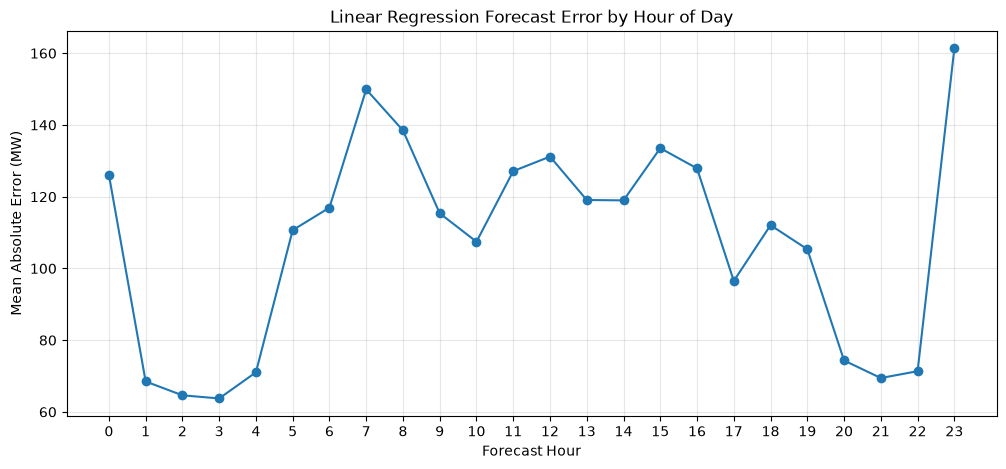

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    error_by_hour.index,
    error_by_hour["MAE"],
    marker="o",
)

plt.title(
    "Linear Regression Forecast Error by Hour of Day"
)
plt.xlabel("Forecast Hour")
plt.ylabel("Mean Absolute Error (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

In [10]:
worst_forecasts = (
    validation.nlargest(
        10,
        "linear_absolute_error",
    )[
        [
            "FORECAST_TIME",
            "target_30m",
            "linear_forecast",
            "linear_absolute_error",
        ]
    ]
)

worst_forecasts

,FORECAST_TIME,target_30m,linear_forecast,linear_absolute_error
186494,2026-04-09 13:45:00,4644.47,3798.680155,845.789845
186505,2026-04-09 14:40:00,5320.79,6151.003612,830.213612
186481,2026-04-09 12:40:00,3871.61,4656.710676,785.100676
186498,2026-04-09 14:05:00,5386.14,4624.215289,761.924711
186482,2026-04-09 12:45:00,3703.26,4455.632382,752.372382
186493,2026-04-09 13:40:00,4410.23,3679.530072,730.699928
186492,2026-04-09 13:35:00,4313.28,3584.367014,728.912986
186497,2026-04-09 14:00:00,5196.43,4473.536318,722.893682
178166,2026-03-11 15:45:00,5327.13,4618.570209,708.559791
178165,2026-03-11 15:40:00,5177.31,4470.765153,706.544847


### Error diagnostics

Forecast error varies substantially by time of day.

The linear model performs particularly well during relatively stable
overnight periods, but errors increase around periods of stronger demand
movement, including the morning ramp. Error is also relatively high near
the end of the day.

The largest individual errors are clustered in a small number of time
periods rather than occurring independently. In particular, several of the
largest validation errors occurred during the afternoon of 9 April 2026.

These results suggest that the relationship between recent demand movement
and demand 30 minutes ahead is not completely linear. Nonlinear interactions
between recent demand, rate of change, time of day, day type and season may
therefore improve forecast performance.

Extreme-error periods should also be revisited after weather variables are
introduced.

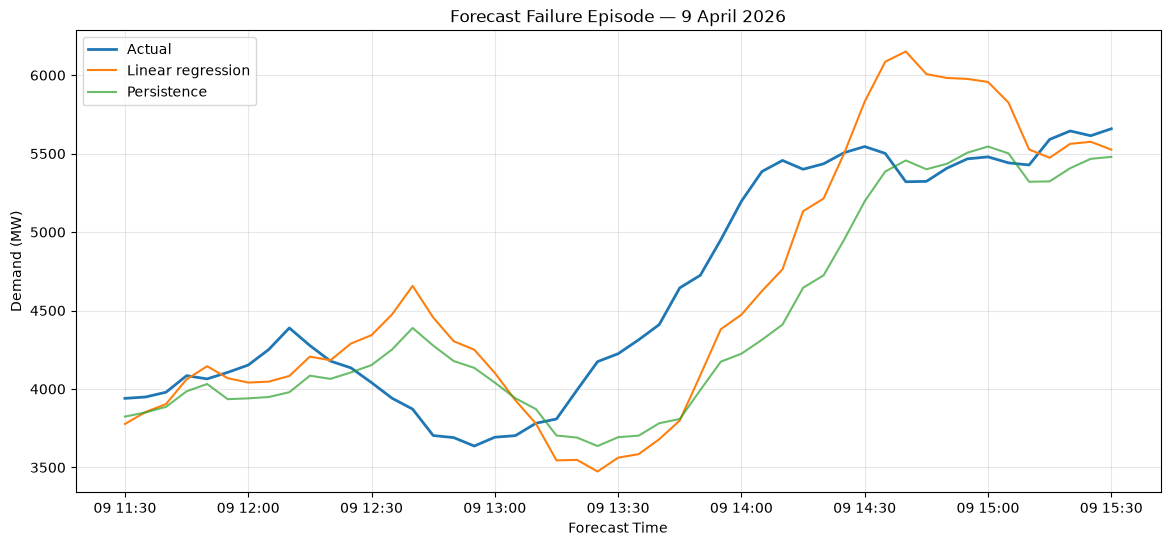

In [11]:
event_start = pd.Timestamp("2026-04-09 11:30")
event_end = pd.Timestamp("2026-04-09 15:30")

event = validation[
    (validation["FORECAST_TIME"] >= event_start)
    & (validation["FORECAST_TIME"] <= event_end)
]

plt.figure(figsize=(14, 6))

plt.plot(
    event["FORECAST_TIME"],
    event["target_30m"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    event["FORECAST_TIME"],
    event["linear_forecast"],
    label="Linear regression",
)

plt.plot(
    event["FORECAST_TIME"],
    event["persistence_forecast"],
    label="Persistence",
    alpha=0.7,
)

plt.title("Forecast Failure Episode — 9 April 2026")
plt.xlabel("Forecast Time")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()